# Thyroid Disease — Data Cleaning & Feature Engineering

Pipeline:
1. Binarize `class` -> `diseased` (class != 3 ⇒ 1, else 0)
2. Drop the original 3-class label
3. Engineer `any_query`, `any_treatment`, `lab_TSH_high`
4. Verify no missing values
5. Save to `data/thyroid_cleaned.csv`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import (load_data, binarize_target, drop_original_class,
                   create_features, preprocess_data)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/thyroid.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (7200, 22)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,class
0,0.73,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0.00060,0.015,0.120,0.082,0.146,3
1,0.24,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00025,0.030,0.143,0.133,0.108,3
2,0.47,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00190,0.024,0.102,0.131,0.078,3
3,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00090,0.017,0.077,0.090,0.085,3
4,0.23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00025,0.026,0.139,0.090,0.153,3


## 2. Missing / Invalid Values

In [3]:
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows      : {df.duplicated().sum()}")

Total missing values: 0
Duplicate rows      : 71


## 3. Binarize Target

In [4]:
df_bin = binarize_target(df)
print("Binary class distribution:")
print(df_bin["diseased"].value_counts())
print(f"Diseased rate: {df_bin['diseased'].mean()*100:.2f}%")

Binary class distribution:
diseased
0    6666
1     534
Name: count, dtype: int64
Diseased rate: 7.42%


## 4. Drop Original 3-class Column

In [5]:
df_dropped = drop_original_class(df_bin)
print(f"Columns after drop: {df_dropped.shape[1]}")
df_dropped.head()

Columns after drop: 22


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,diseased
0,0.73,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0.00060,0.015,0.120,0.082,0.146,0
1,0.24,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00025,0.030,0.143,0.133,0.108,0
2,0.47,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00190,0.024,0.102,0.131,0.078,0
3,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00090,0.017,0.077,0.090,0.085,0
4,0.23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00025,0.026,0.139,0.090,0.153,0


## 5. Feature Engineering

In [6]:
df_feat = create_features(df_dropped)
new_cols = [c for c in df_feat.columns if c not in df_dropped.columns]
print(f"New features: {new_cols}")
df_feat[new_cols + ["diseased"]].head()

New features: ['any_query', 'any_treatment', 'lab_TSH_high']


,any_query,any_treatment,lab_TSH_high,diseased
0,0,1,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0


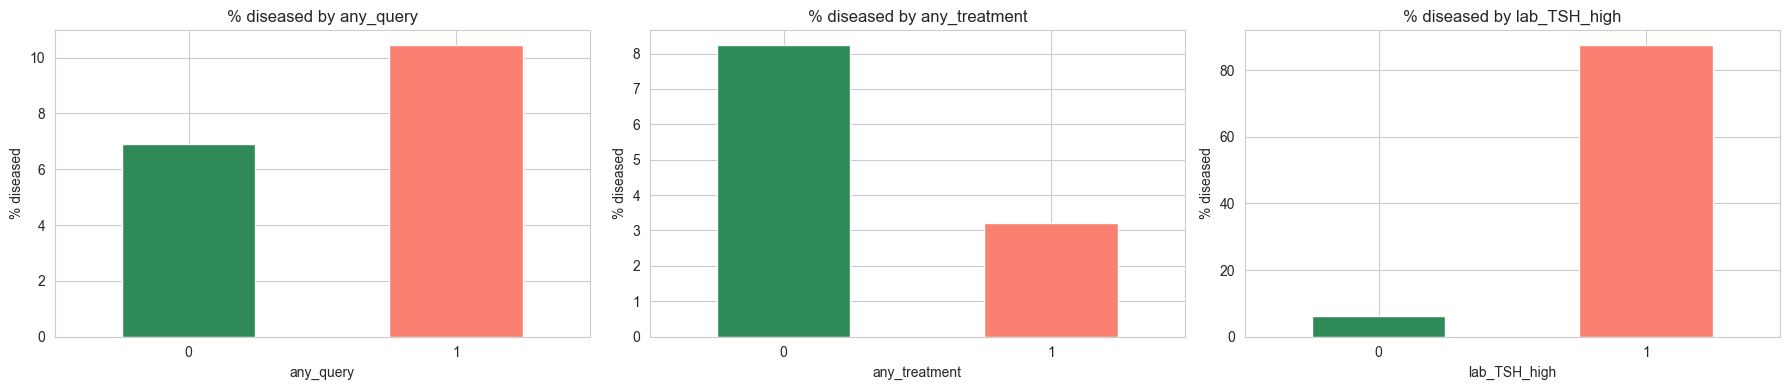

In [7]:
# Visualize the new features
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(new_cols):
    rate = df_feat.groupby(col)["diseased"].mean() * 100
    rate.plot(kind="bar", ax=axes[i],
              color=["seagreen","salmon"])
    axes[i].set_title(f"% diseased by {col}")
    axes[i].set_ylabel("% diseased")
    axes[i].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 6. Run the Full Pipeline

In [8]:
df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (7200, 25)
Missing values : 0


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,psych,TSH,T3,TT4,T4U,FTI,diseased,any_query,any_treatment,lab_TSH_high
0,0.73,0,1,0,0,0,0,0,1,0,...,0,0.00060,0.015,0.120,0.082,0.146,0,0,1,0
1,0.24,0,0,0,0,0,0,0,0,0,...,0,0.00025,0.030,0.143,0.133,0.108,0,0,0,0
2,0.47,0,0,0,0,0,0,0,0,0,...,0,0.00190,0.024,0.102,0.131,0.078,0,0,0,0
3,0.64,1,0,0,0,0,0,0,0,0,...,0,0.00090,0.017,0.077,0.090,0.085,0,0,0,0
4,0.23,0,0,0,0,0,0,0,0,0,...,0,0.00025,0.026,0.139,0.090,0.153,0,0,0,0


## 7. Sanity Checks & Save

In [9]:
assert df_processed["diseased"].isin([0, 1]).all()
assert df_processed.isnull().sum().sum() == 0
assert "class" not in df_processed.columns
print("All checks passed.")

All checks passed.


In [10]:
df_processed.to_csv("data/thyroid_cleaned.csv", index=False)
print(f"Saved data/thyroid_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/thyroid_cleaned.csv (7200 rows, 25 cols)
